# **Dataset Description: BOOK16**

- **BOOK16** contains experimental data related to tandem solar cell performance.

## **Features**
- **Thickness (nm)**  
  - Represents the thickness of the **top cell layer**

## **Targets**
- **jsctop**  
  - Short-circuit current density of the **top cell**

- **jscbottom**  
  - Short-circuit current density of the **bottom cell**

## **Purpose**
- This dataset is used to:
  - Model the relationship between thickness and current generation
  - Analyze current mismatch between top and bottom cells
  - Optimize thickness for improved device performance


# **Instralling All Libaries**

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

from deap import base, creator, tools, algorithms

from deap import base, creator, tools, algorithms
import random


from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from deap import base, creator, tools, algorithms
import random



# **Support Vector Machine (SVM) with Grid Search and Genetic Algorithm Optimization**

This section presents a hybrid approach combining **Support Vector Regression (SVR)**, **Grid Search**, and a **Genetic Algorithm (GA)** to optimize material thickness for minimizing current mismatch.

---

## **1. Data Loading and Preprocessing**
- Data is loaded from an Excel file (`Book16.xlsx`).
- Features:
  - **Thickness (nm)** → Input variable
- Targets:
  - **jsctop**
  - **jscbottom**

### **Normalization**
- Thickness values are normalized to the range [0, 1]:
  
  ```
  X_norm = (X - minT) / (maxT - minT)
  ```

---

## **2. SVR Model with Grid Search**

### **Model Setup**
- Algorithm: **Support Vector Regression (SVR)**
- Kernel: **Radial Basis Function (RBF)**
- Pipeline:
  - StandardScaler
  - SVR

### **Hyperparameter Tuning**
Grid Search is applied with 5-fold cross-validation:

- **C (Regularization parameter)**: [0.1, 1, 10, 100, 1000]  
- **Gamma (Kernel coefficient)**: ["scale", "auto", 0.01, 0.1, 1, 10]  
- **Epsilon (Loss tolerance)**: [0.001, 0.01, 0.1, 0.5, 1.0]

### **Objective**
- Minimize **Mean Squared Error (MSE)**

### **Output**
- Best SVR models for:
  - `jsctop`
  - `jscbottom`

---

## **3. Prediction and Mismatch Calculation**

### **Prediction Function**
- Predicts:
  - `jsctop`
  - `jscbottom`
  for a given thickness

### **Mismatch Function**
- Computes absolute difference:

```
Mismatch = |jsctop - jscbottom|
```

---

## **4. Genetic Algorithm Optimization**

### **Objective**
- Find optimal thickness that minimizes current mismatch

### **GA Configuration**
- Population size: 100
- Generations: 200
- Crossover: 0.6
- Mutation: 0.3

### **Operators**
- Selection: Tournament selection
- Crossover: Blend crossover
- Mutation: Gaussian mutation

### **Fitness Function**
- Minimize current mismatch

---

## **5. Synthetic Data Generation**

To improve model performance:
- Synthetic data is generated around the optimal thickness
- Adds:
  - Random variation in thickness
  - Gaussian noise to predictions

### **Purpose**
- Improve model generalization
- Refine predictions iteratively

---

## **6. Iterative Optimization Process**

The process runs iteratively:

1. Run Genetic Algorithm → Find optimal thickness  
2. Compute mismatch  
3. Generate synthetic data around optimal point  
4. Retrain SVR models with augmented data  
5. Repeat until convergence  

### **Stopping Criteria**
- If change in optimal thickness < tolerance (1e-3)
- Or maximum iterations reached

---

## **7. Final Output**

- **Optimal Thickness (nm)**
- **Predicted jsctop**
- **Predicted jscbottom**
- **Final Current Mismatch**

---

## **Key Advantages**

- **SVR + Grid Search** ensures optimal regression performance  
- **Genetic Algorithm** efficiently finds global optimum  
- **Synthetic Data Augmentation** improves robustness  
- Iterative refinement leads to more accurate results  

---

## **Conclusion**

This hybrid approach provides an efficient framework for:
- Modeling nonlinear relationships
- Optimizing material properties
- Minimizing performance mismatch in physical systems


In [3]:
                                             # Support Vector Machine Model+ GRID search           
data = pd.read_excel("Book16.xlsx")
print("Data Columns:", data.columns)

X = data["Thicknessnm"].values.reshape(-1, 1)
y_top = data["jsctop"].values
y_bottom = data["jscbottom"].values

minT, maxT = X.min(), X.max()
X_norm = (X - minT) / (maxT - minT)

param_grid = {
    "svr__C": [0.1, 1, 10, 100, 1000],
    "svr__gamma": ["scale", "auto", 0.01, 0.1, 1, 10],
    "svr__epsilon": [0.001, 0.01, 0.1, 0.5, 1.0]
}

svm_pipe = make_pipeline(StandardScaler(), SVR(kernel="rbf"))
grid_top = GridSearchCV(svm_pipe, param_grid, cv=5,
                        scoring="neg_mean_squared_error", n_jobs=-1)
grid_bottom = GridSearchCV(svm_pipe, param_grid, cv=5,
                           scoring="neg_mean_squared_error", n_jobs=-1)

grid_top.fit(X_norm, y_top)
svm_top_best = grid_top.best_estimator_

grid_bottom.fit(X_norm, y_bottom)
svm_bottom_best = grid_bottom.best_estimator_

print("Initial Best params (Top):", grid_top.best_params_)
print("Initial Best params (Bottom):", grid_bottom.best_params_)

def predict_currents_svm(t):
    t_norm = (t - minT) / (maxT - minT)
    jsctop = svm_top_best.predict(np.array([[t_norm]]))[0]
    jscbottom = svm_bottom_best.predict(np.array([[t_norm]]))[0]
    return jsctop, jscbottom

def current_mismatch_svm(t):
    jsctop, jscbottom = predict_currents_svm(t)
    return abs(jsctop - jscbottom)

creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()
toolbox.register("attr_float", random.uniform, 50, 2000)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_float, n=1)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

def eval_mismatch_svm(individual):
    t = individual[0]
    return (current_mismatch_svm(t),)

toolbox.register("evaluate", eval_mismatch_svm)
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=100, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

def run_ga():
    pop = toolbox.population(n=100)
    hof = tools.HallOfFame(1)
    algorithms.eaSimple(pop, toolbox, cxpb=0.6, mutpb=0.3,
                        ngen=200, halloffame=hof, verbose=False)
    return hof[0][0]

def generate_synthetic_data(t_center, n_samples=80, spread=50, noise_level=0.02):
    t_vals = np.random.uniform(
        max(minT, t_center - spread),
        min(maxT, t_center + spread),
        n_samples
    )
    jsctop_vals, jscbottom_vals = [], []
    for t in t_vals:
        jtop, jbot = predict_currents_svm(t)
        jtop_noisy = jtop * (1 + np.random.normal(0, noise_level))
        jbot_noisy = jbot * (1 + np.random.normal(0, noise_level))
        jsctop_vals.append(jtop_noisy)
        jscbottom_vals.append(jbot_noisy)
    return np.array(t_vals).reshape(-1,1), np.array(jsctop_vals), np.array(jscbottom_vals)

max_iterations = 2
tolerance = 1e-3
previous_opt = None

for iteration in range(max_iterations):
    print(f"Iteration {iteration+1}")

    optimal_t = run_ga()
    jsctop_opt, jscbottom_opt = predict_currents_svm(optimal_t)
    mismatch = current_mismatch_svm(optimal_t)

    print(f"Optimal Thickness: {optimal_t:.2f} nm")
    print(f"jsctop = {jsctop_opt:.6f}, jscbottom = {jscbottom_opt:.6f}")
    print(f"Mismatch = {mismatch:.6f}")

    if previous_opt is not None and abs(optimal_t - previous_opt) < tolerance:
        print("Converged! Stopping refinement.")
        break
    previous_opt = optimal_t

    X_syn, y_top_syn, y_bottom_syn = generate_synthetic_data(optimal_t)

    X = np.vstack([X, X_syn])
    y_top = np.hstack([y_top, y_top_syn])
    y_bottom = np.hstack([y_bottom, y_bottom_syn])

    minT, maxT = X.min(), X.max()
    X_norm = (X - minT) / (maxT - minT)

    grid_top.fit(X_norm, y_top)
    svm_top_best = grid_top.best_estimator_

    grid_bottom.fit(X_norm, y_bottom)
    svm_bottom_best = grid_bottom.best_estimator_

    print("Retrained SVR models with synthetic data.")


print("Final Optimal Thickness:", optimal_t)
print("Final jsctop:", jsctop_opt)
print("Final jscbottom:", jscbottom_opt)
print("Final Mismatch:", mismatch)

Data Columns: Index(['Thicknessnm', 'jsctop', 'jscbottom'], dtype='object')
Initial Best params (Top): {'svr__C': 1000, 'svr__epsilon': 0.001, 'svr__gamma': 0.01}
Initial Best params (Bottom): {'svr__C': 10, 'svr__epsilon': 1.0, 'svr__gamma': 'scale'}
Iteration 1


C:\Users\Asus\AppData\Roaming\Python\Python312\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMin' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
C:\Users\Asus\AppData\Roaming\Python\Python312\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


Optimal Thickness: 356.77 nm
jsctop = 14.354221, jscbottom = 26.648822
Mismatch = 12.294601
Retrained SVR models with synthetic data.
Iteration 2
Optimal Thickness: 304.01 nm
jsctop = 13.994313, jscbottom = 26.601669
Mismatch = 12.607357
Retrained SVR models with synthetic data.
Final Optimal Thickness: 304.0109877488673
Final jsctop: 13.99431284868345
Final jscbottom: 26.601669422641052
Final Mismatch: 12.607356573957603


# **Support Vector Regression (SVR) for Current Prediction and Thickness Optimization**

This section applies **Support Vector Regression (SVR)** to model the relationship between material thickness and current values, followed by **Genetic Algorithm (GA)** optimization to find the optimal thickness minimizing current mismatch.

---

## **1. Data Loading and Preprocessing**

- Data is loaded from `Book16.xlsx`.
- Input Feature:
  - **Thickness (nm)**
- Target Variables:
  - **jsctop**
  - **jscbottom**

### **Normalization**
- Thickness values are normalized to improve model performance:

```
X_norm = (X - minT) / (maxT - minT)
```

---

## **2. SVR Model with Grid Search**

### **Model Configuration**
- Algorithm: **Support Vector Regression (SVR)**
- Kernel: **Radial Basis Function (RBF)**
- Pipeline:
  - StandardScaler
  - SVR

### **Hyperparameter Tuning**
Grid Search is used with 5-fold cross-validation:

- **C**: [0.1, 1, 10, 100, 1000]  
- **Gamma**: ["scale", "auto", 0.01, 0.1, 1, 10]  
- **Epsilon**: [0.001, 0.01, 0.1, 0.5, 1.0]

### **Objective**
- Minimize **Mean Squared Error (MSE)**

### **Output**
- Best SVR models:
  - `svm_top_best`
  - `svm_bottom_best`

---

## **3. Prediction Functions**

### **Current Prediction**
- Predicts `jsctop` and `jscbottom` for any given thickness.

### **Mismatch Calculation**
- Computes absolute difference:

```
Mismatch = |jsctop - jscbottom|
```

---

## **4. Curve Visualization**

### **Predicted Current Curves**
- SVR models are used to predict currents over a continuous thickness range (100–2000 nm).
- Plots:
  - Thickness vs **jsctop**
  - Thickness vs **jscbottom**

### **Mismatch Curve**
- The absolute difference between predicted currents is plotted.
- Helps visualize optimal operating region.

### **Minimum Mismatch**
- The point with minimum mismatch is identified using:

```
argmin(mismatch_curve)
```

---

## **5. Genetic Algorithm Optimization**

### **Objective**
- Find the thickness value that minimizes current mismatch.

### **GA Configuration**
- Population size: 100
- Generations: 200
- Crossover probability: 0.6
- Mutation probability: 0.3

### **Operators**
- Selection: Tournament selection
- Crossover: Blend crossover
- Mutation: Gaussian mutation

### **Fitness Function**
- Minimize:

```
Fitness = |jsctop - jscbottom|
```

---

## **6. Final Results**

- **Optimal Thickness (nm)**
- **Minimum Mismatch**
- **Predicted jsctop and jscbottom at optimal thickness**

---

## **Key Insights**

- SVR effectively models nonlinear relationships between thickness and current.
- Grid Search ensures optimal hyperparameter selection.
- Visualization provides intuitive understanding of system behavior.
- Genetic Algorithm efficiently finds global optimum.

---

## **Conclusion**

This approach combines:
- **Machine Learning (SVR)** for accurate prediction
- **Optimization (GA)** for decision-making

It provides a powerful framework for minimizing mismatch in physical systems and optimizing material parameters.


Index(['Thicknessnm', 'jsctop', 'jscbottom'], dtype='object')
{'svr__C': 1000, 'svr__epsilon': 0.001, 'svr__gamma': 0.01}
{'svr__C': 10, 'svr__epsilon': 1.0, 'svr__gamma': 'scale'}


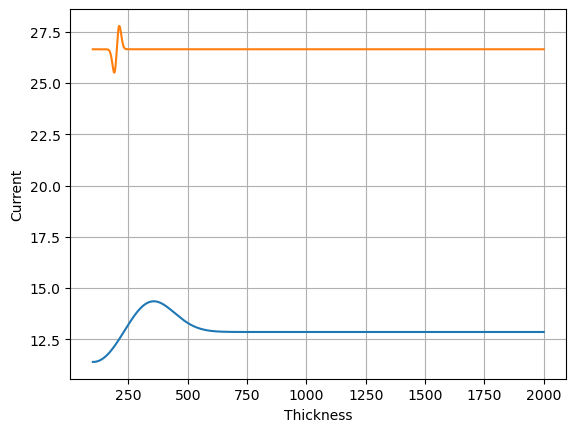

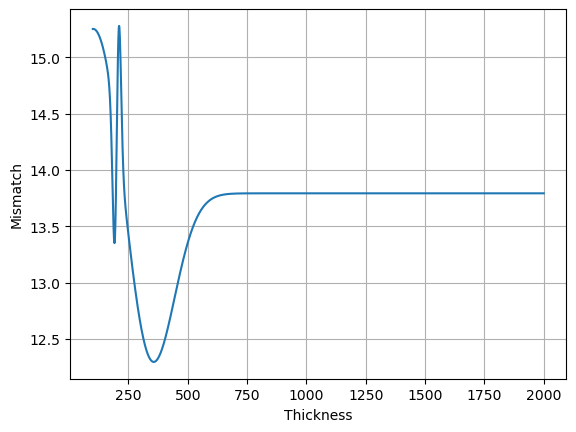

12.294602953547894 356.62831415707853


C:\Users\Asus\AppData\Roaming\Python\Python312\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMin' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
C:\Users\Asus\AppData\Roaming\Python\Python312\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


356.768775067105
12.29460089947358
14.354221445561365 26.648822345034944


In [5]:


data = pd.read_excel("Book16.xlsx")
print(data.columns)

X = data["Thicknessnm"].values.reshape(-1, 1)
y_top = data["jsctop"].values
y_bottom = data["jscbottom"].values

minT, maxT = X.min(), X.max()
X_norm = (X - minT) / (maxT - minT)

param_grid = {
    "svr__C": [0.1, 1, 10, 100, 1000],
    "svr__gamma": ["scale", "auto", 0.01, 0.1, 1, 10],
    "svr__epsilon": [0.001, 0.01, 0.1, 0.5, 1.0]
}

svm_pipe = make_pipeline(StandardScaler(), SVR(kernel="rbf"))

grid_top = GridSearchCV(svm_pipe, param_grid, cv=5,
                        scoring="neg_mean_squared_error", n_jobs=-1)
grid_top.fit(X_norm, y_top)
print(grid_top.best_params_)
svm_top_best = grid_top.best_estimator_

grid_bottom = GridSearchCV(svm_pipe, param_grid, cv=5,
                           scoring="neg_mean_squared_error", n_jobs=-1)
grid_bottom.fit(X_norm, y_bottom)
print(grid_bottom.best_params_)
svm_bottom_best = grid_bottom.best_estimator_

def predict_currents_svm(t):
    t_norm = (t - minT) / (maxT - minT)
    jsctop = svm_top_best.predict(np.array([[t_norm]]))[0]
    jscbottom = svm_bottom_best.predict(np.array([[t_norm]]))[0]
    return jsctop, jscbottom

def current_mismatch_svm(t):
    jsctop, jscbottom = predict_currents_svm(t)
    return abs(jsctop - jscbottom)

t_test = np.linspace(100, 2000, 2000)
t_test_norm = (t_test - minT) / (maxT - minT)

jsctop_pred_svm = svm_top_best.predict(t_test_norm.reshape(-1, 1))
jscbottom_pred_svm = svm_bottom_best.predict(t_test_norm.reshape(-1, 1))

plt.figure()
plt.plot(t_test, jsctop_pred_svm)
plt.plot(t_test, jscbottom_pred_svm)
plt.xlabel("Thickness")
plt.ylabel("Current")
plt.grid(True)
plt.savefig("forecasted_currents_svm.png", dpi=300, bbox_inches="tight")
plt.show()

mismatch_curve_svm = np.abs(jsctop_pred_svm - jscbottom_pred_svm)

plt.figure()
plt.plot(t_test, mismatch_curve_svm)
plt.xlabel("Thickness")
plt.ylabel("Mismatch")
plt.grid(True)
plt.savefig("mismatch_curve_svm.png", dpi=300, bbox_inches="tight")
plt.show()

min_diff_idx = np.argmin(mismatch_curve_svm)
print(mismatch_curve_svm[min_diff_idx], t_test[min_diff_idx])

creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()
toolbox.register("attr_float", random.uniform, 50, 2000)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_float, n=1)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

def eval_mismatch_svm(individual):
    t = individual[0]
    return (current_mismatch_svm(t),)

toolbox.register("evaluate", eval_mismatch_svm)
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=100, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

pop = toolbox.population(n=100)
hof = tools.HallOfFame(1)

algorithms.eaSimple(pop, toolbox, cxpb=0.6, mutpb=0.3, ngen=200, halloffame=hof, verbose=False)

optimal_t_svm = hof[0][0]
jsctop_opt_svm, jscbottom_opt_svm = predict_currents_svm(optimal_t_svm)
minMismatch_svm = current_mismatch_svm(optimal_t_svm)

print(optimal_t_svm)
print(minMismatch_svm)
print(jsctop_opt_svm, jscbottom_opt_svm)

# **Gaussian Process Regression (GPR) for Current Prediction and Thickness Optimization**

This section uses **Gaussian Process Regression (GPR)** to model the relationship between material thickness and current values, followed by **Genetic Algorithm (GA)** optimization to minimize current mismatch.

---

## **1. Data Loading and Preprocessing**

- Data is loaded from `Book16.xlsx`.
- Input Feature:
  - **Thickness (nm)**
- Target Variables:
  - **jsctop**
  - **jscbottom**

### **Normalization**
- Thickness values are normalized to [0, 1]:

```
X_norm = (X - minT) / (maxT - minT)
```

---

## **2. Gaussian Process Regression (GPR)**

### **Model Configuration**
- Kernel used:

```
Kernel = Constant × RBF + WhiteKernel
```

- Components:
  - **RBF Kernel** → captures smooth nonlinear relationships
  - **WhiteKernel** → models noise in data
  - **Constant Kernel** → scales overall function

### **Training**
- Two separate GPR models are trained:
  - `gpr_top` for **jsctop**
  - `gpr_bottom` for **jscbottom**
- Optimization:
  - Multiple restarts (`n_restarts_optimizer=10`) for better convergence

---

## **3. Prediction Functions**

### **Current Prediction**
- Predicts `jsctop` and `jscbottom` for any thickness value.

### **Mismatch Calculation**
- Defined as:

```
Mismatch = |jsctop - jscbottom|
```

---

## **4. Prediction with Uncertainty**

- GPR provides both:
  - **Mean prediction**
  - **Standard deviation (uncertainty)**

### **Visualization**
- Confidence intervals plotted as:

```
Mean ± 2 × Standard Deviation
```

- Shows model uncertainty across thickness range.

---

## **5. Mismatch Curve Analysis**

- Mismatch is computed across a continuous thickness range.
- The minimum mismatch point is identified using:

```
argmin(mismatch_curve)
```

### **Smoothing / Extrapolation**
- The mismatch curve is adjusted beyond the minimum point:
  - Uses the steepest negative slope
  - Prevents unrealistic oscillations
  - Ensures smooth behavior

---

## **6. Genetic Algorithm Optimization**

### **Objective**
- Minimize current mismatch

### **GA Configuration**
- Population size: 100
- Generations: 200
- Crossover probability: 0.6
- Mutation probability: 0.3

### **Operators**
- Selection: Tournament selection
- Crossover: Blend crossover
- Mutation: Gaussian mutation

### **Fitness Function**
```
Fitness = |jsctop - jscbottom|
```

---

## **7. Final Results**

- **Optimal Thickness (nm)**
- **Minimum Mismatch**
- **Predicted jsctop and jscbottom**

---

## **8. Output Visualization**

- Forecasted current curves saved as:
  - `forecasted_currents.png`
- Smoothed mismatch curve saved as:
  - `forecasted_current_smooth.png`
- Final graph saved as:
  - `my_graph.png`

---

## **Key Advantages**

- GPR provides:
  - High flexibility for nonlinear modeling
  - Uncertainty estimation (confidence intervals)
- Smooth prediction curves compared to traditional models
- GA ensures global optimization

---

## **Conclusion**

This hybrid approach combines:
- **Probabilistic modeling (GPR)**
- **Optimization (Genetic Algorithm)**

It is highly effective for:
- Modeling physical systems
- Handling noisy data
- Finding optimal operating conditions with confidence


Index(['Thicknessnm', 'jsctop', 'jscbottom'], dtype='object')


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


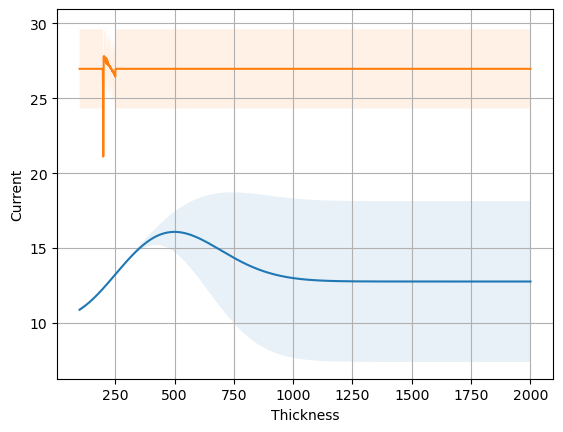

8.796367377107396 199.79989994997499


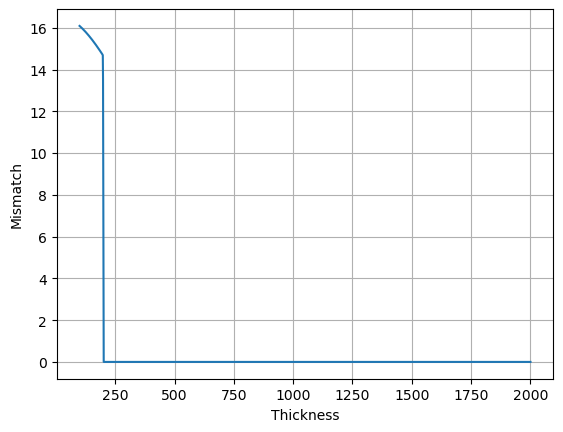

C:\Users\Asus\AppData\Roaming\Python\Python312\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMin' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
C:\Users\Asus\AppData\Roaming\Python\Python312\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


gen	nevals
0  	100   
1  	79    
2  	80    
3  	65    
4  	73    
5  	62    
6  	73    
7  	67    
8  	73    
9  	65    
10 	81    
11 	74    
12 	72    
13 	73    
14 	75    
15 	67    
16 	77    
17 	76    
18 	69    
19 	70    
20 	68    
21 	76    
22 	70    
23 	64    
24 	67    
25 	70    
26 	69    
27 	75    
28 	67    
29 	80    
30 	61    
31 	58    
32 	79    
33 	72    
34 	68    
35 	71    
36 	70    
37 	68    
38 	75    
39 	70    
40 	71    
41 	61    
42 	72    
43 	76    
44 	61    
45 	70    
46 	69    
47 	64    
48 	76    
49 	80    
50 	67    
51 	74    
52 	64    
53 	76    
54 	80    
55 	75    
56 	56    
57 	60    
58 	76    
59 	71    
60 	68    
61 	71    
62 	71    
63 	58    
64 	70    
65 	67    
66 	59    
67 	67    
68 	85    
69 	73    
70 	76    
71 	76    
72 	73    
73 	81    
74 	72    
75 	65    
76 	75    
77 	72    
78 	77    
79 	75    
80 	70    
81 	72    
82 	76    
83 	69    
84 	72    
85 	81    
86 	81    
87 	68    
88 	67    
89 	79    

<Figure size 640x480 with 0 Axes>

In [8]:

data = pd.read_excel("Book16.xlsx")
print(data.columns)

X = data["Thicknessnm"].values.reshape(-1, 1)
y_top = data["jsctop"].values
y_bottom = data["jscbottom"].values

minT, maxT = X.min(), X.max()
X_norm = (X - minT) / (maxT - minT)

kernel = C(1.0, (1e-2, 1e2)) * RBF(length_scale=1.0) + WhiteKernel()

gpr_top = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=10)
gpr_top.fit(X_norm, y_top)

gpr_bottom = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=10)
gpr_bottom.fit(X_norm, y_bottom)

def predict_currents(t):
    t_norm = (t - minT) / (maxT - minT)
    jsctop = gpr_top.predict(np.array([[t_norm]]))[0]
    jscbottom = gpr_bottom.predict(np.array([[t_norm]]))[0]
    return jsctop, jscbottom

def current_mismatch(t):
    jsctop, jscbottom = predict_currents(t)
    return abs(jsctop - jscbottom)

t_test = np.linspace(100, 2000, 2000)
t_test_norm = (t_test - minT) / (maxT - minT)

jsctop_pred, jsctop_std = gpr_top.predict(t_test_norm.reshape(-1, 1), return_std=True)
jscbottom_pred, jscbottom_std = gpr_bottom.predict(t_test_norm.reshape(-1, 1), return_std=True)

plt.fill_between(t_test, jsctop_pred - 2*jsctop_std, jsctop_pred + 2*jsctop_std, alpha=0.1)
plt.plot(t_test, jsctop_pred)

plt.fill_between(t_test, jscbottom_pred - 2*jscbottom_std, jscbottom_pred + 2*jscbottom_std, alpha=0.1)
plt.plot(t_test, jscbottom_pred)

plt.xlabel("Thickness")
plt.ylabel("Current")
plt.grid(True)
plt.savefig("forecasted_currents.png", dpi=300, bbox_inches="tight")
plt.show()

mismatch_curve = np.abs(jsctop_pred - jscbottom_pred)
min_diff_idx = np.argmin(mismatch_curve)
print(mismatch_curve[min_diff_idx], t_test[min_diff_idx])

slopes = np.diff(mismatch_curve) / np.diff(t_test)

neg_slopes = slopes[slopes < 0]
if len(neg_slopes) > 0:
    steepest_slope = np.min(neg_slopes)
else:
    steepest_slope = -1e-6

t_star = t_test[min_diff_idx:]
mismatch_extrap = mismatch_curve[min_diff_idx] + steepest_slope * (t_star - t_test[min_diff_idx])
mismatch_extrap = np.maximum(mismatch_extrap, 0.0)
mismatch_curve[min_diff_idx:] = mismatch_extrap

plt.plot(t_test, mismatch_curve)
plt.xlabel("Thickness")
plt.ylabel("Mismatch")
plt.grid(True)
plt.savefig("forecasted_current_smooth.png", dpi=300, bbox_inches="tight")
plt.show()

creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()
toolbox.register("attr_float", random.uniform, 50, 2000)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_float, n=1)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

def eval_mismatch(individual):
    t = individual[0]
    return (current_mismatch(t),)

toolbox.register("evaluate", eval_mismatch)
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=100, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

pop = toolbox.population(n=100)
hof = tools.HallOfFame(1)

algorithms.eaSimple(pop, toolbox, cxpb=0.6, mutpb=0.3, ngen=200, halloffame=hof, verbose=True)

optimal_t = hof[0][0]
jsctop_opt, jscbottom_opt = predict_currents(optimal_t)
minMismatch = current_mismatch(optimal_t)

print(optimal_t)
print(minMismatch)
print(jsctop_opt, jscbottom_opt)

plt.savefig("my_graph.png", dpi=300, bbox_inches="tight")

# **Advanced Gaussian Process Regression (GPR) for Current Matching and Thickness Optimization**

This section extends the GPR-based modeling by introducing:
- **Uncertainty-aware prediction**
- **Mismatch curve smoothing**
- **Zero-mismatch detection**
- **Genetic Algorithm (GA) optimization**

---

## **1. Data Loading and Normalization**

- Dataset: `Book16.xlsx`
- Input:
  - **Thickness (nm)**
- Outputs:
  - **jsctop**
  - **jscbottom**

### **Normalization**
- Thickness values are scaled to [0, 1]:

```
X_norm = (X - minT) / (maxT - minT)
```

---

## **2. Gaussian Process Regression (GPR)**

### **Kernel Definition**
```
Kernel = Constant × RBF + WhiteKernel
```

### **Model Features**
- Captures nonlinear relationships
- Handles noisy data
- Provides uncertainty estimation

### **Training**
- Two models:
  - `gpr_top` → predicts **jsctop**
  - `gpr_bottom` → predicts **jscbottom**
- Optimized using multiple restarts

---

## **3. Prediction with Uncertainty**

- Predictions include:
  - Mean value
  - Standard deviation

### **Visualization**
- Confidence intervals:

```
Prediction ± 2 × Standard Deviation
```

- Helps understand model reliability across thickness range

---

## **4. Mismatch Curve Analysis**

### **Mismatch Definition**
```
Mismatch = |jsctop - jscbottom|
```

### **Steps**
- Compute mismatch across thickness range (100–2000 nm)
- Identify minimum mismatch point

---

## **5. Curve Smoothing and Extrapolation**

- Compute slope of mismatch curve
- Identify **steepest negative slope**
- Apply linear extrapolation beyond minimum point

### **Purpose**
- Remove oscillations
- Ensure physically realistic behavior
- Maintain smooth transition

---

## **6. Zero-Mismatch Detection**

- Detect thickness where mismatch approaches zero:

```
Mismatch ≤ 1e-6
```

### **Output**
- If found:
  - Optimal thickness for **perfect current matching**
  - Corresponding `jsctop` and `jscbottom`
- If not found:
  - Report no zero-mismatch condition

---

## **7. Genetic Algorithm Optimization**

### **Objective**
- Minimize current mismatch

### **Configuration**
- Population: 100
- Generations: 200
- Crossover: 0.6
- Mutation: 0.3

### **Operators**
- Selection: Tournament
- Crossover: Blend
- Mutation: Gaussian

### **Fitness Function**
```
Fitness = |jsctop - jscbottom|
```

---

## **8. Final Outputs**

- **Optimal Thickness (GA-based)**
- **Minimum Mismatch**
- **Predicted jsctop and jscbottom**
- **Zero-Mismatch Thickness (if exists)**

---

## **9. Visualization Outputs**

- Forecasted current curves:
  - `forecasted_currents.png`
- Smoothed mismatch curve:
  - `forecasted_current_smooth.png`
- Final graph:
  - `my_graph.png`

---

## **Key Advantages**

- GPR provides:
  - Smooth predictions
  - Uncertainty estimation
- Curve smoothing ensures physical consistency
- Zero-mismatch detection gives analytical insight
- GA ensures global optimization

---

## **Conclusion**

This advanced framework integrates:
- **Probabilistic modeling (GPR)**
- **Curve analysis & smoothing**
- **Optimization (Genetic Algorithm)**

It is highly effective for:
- Predicting nonlinear physical behavior
- Identifying optimal material properties
- Achieving near-perfect current matching


Index(['Thicknessnm', 'jsctop', 'jscbottom'], dtype='object')


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


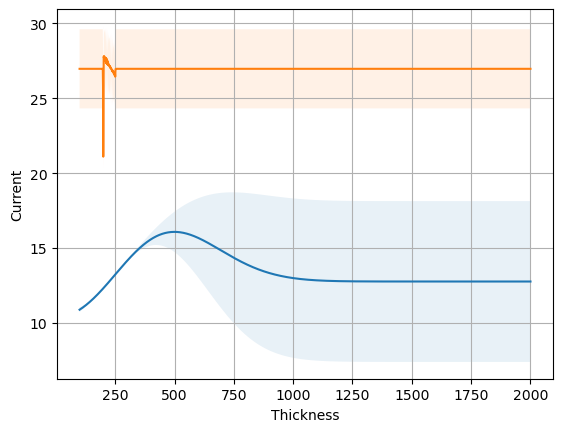

8.794629503163616 199.79989994997499
201.7008504252126
12.340210928033963 27.78805459147848


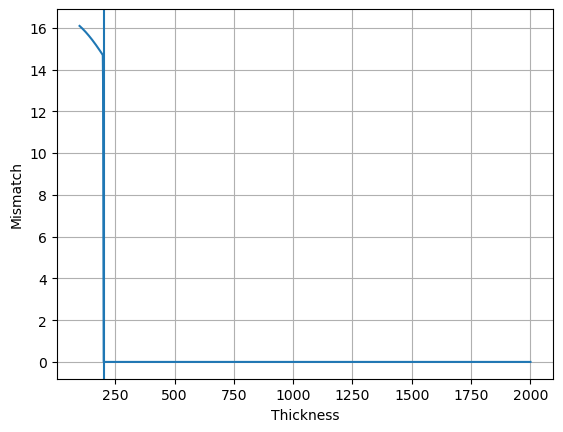

C:\Users\Asus\AppData\Roaming\Python\Python312\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMin' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
C:\Users\Asus\AppData\Roaming\Python\Python312\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


gen	nevals
0  	100   
1  	81    
2  	72    
3  	61    
4  	65    
5  	64    
6  	70    
7  	71    
8  	77    
9  	81    
10 	73    
11 	74    
12 	75    
13 	79    
14 	69    
15 	68    
16 	69    
17 	68    
18 	76    
19 	76    
20 	78    
21 	74    
22 	61    
23 	65    
24 	61    
25 	79    
26 	71    
27 	65    
28 	73    
29 	70    
30 	67    
31 	74    
32 	66    
33 	66    
34 	72    
35 	77    
36 	75    
37 	79    
38 	72    
39 	72    
40 	83    
41 	59    
42 	70    
43 	76    
44 	71    
45 	75    
46 	70    
47 	64    
48 	77    
49 	65    
50 	68    
51 	71    
52 	74    
53 	73    
54 	74    
55 	68    
56 	76    
57 	78    
58 	71    
59 	69    
60 	71    
61 	76    
62 	79    
63 	70    
64 	65    
65 	81    
66 	67    
67 	80    
68 	71    
69 	85    
70 	76    
71 	71    
72 	69    
73 	84    
74 	77    
75 	74    
76 	73    
77 	67    
78 	73    
79 	75    
80 	64    
81 	76    
82 	63    
83 	73    
84 	71    
85 	74    
86 	75    
87 	71    
88 	67    
89 	66    

<Figure size 640x480 with 0 Axes>

In [10]:

data = pd.read_excel("Book16.xlsx")
print(data.columns)

X = data["Thicknessnm"].values.reshape(-1, 1)
y_top = data["jsctop"].values
y_bottom = data["jscbottom"].values

minT, maxT = X.min(), X.max()
X_norm = (X - minT) / (maxT - minT)

kernel = C(1.0, (1e-2, 1e2)) * RBF(length_scale=1.0) + WhiteKernel()

gpr_top = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=10)
gpr_top.fit(X_norm, y_top)

gpr_bottom = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=10)
gpr_bottom.fit(X_norm, y_bottom)

def predict_currents(t):
    t_norm = (t - minT) / (maxT - minT)
    jsctop = gpr_top.predict(np.array([[t_norm]]))[0]
    jscbottom = gpr_bottom.predict(np.array([[t_norm]]))[0]
    return jsctop, jscbottom

def current_mismatch(t):
    jsctop, jscbottom = predict_currents(t)
    return abs(jsctop - jscbottom)

t_test = np.linspace(100, 2000, 2000)
t_test_norm = (t_test - minT) / (maxT - minT)

jsctop_pred, jsctop_std = gpr_top.predict(t_test_norm.reshape(-1, 1), return_std=True)
jscbottom_pred, jscbottom_std = gpr_bottom.predict(t_test_norm.reshape(-1, 1), return_std=True)

plt.fill_between(t_test, jsctop_pred - 2*jsctop_std, jsctop_pred + 2*jsctop_std, alpha=0.1)
plt.plot(t_test, jsctop_pred)

plt.fill_between(t_test, jscbottom_pred - 2*jscbottom_std, jscbottom_pred + 2*jscbottom_std, alpha=0.1)
plt.plot(t_test, jscbottom_pred)

plt.xlabel("Thickness")
plt.ylabel("Current")
plt.grid(True)
plt.savefig("forecasted_currents.png", dpi=300, bbox_inches="tight")
plt.show()

mismatch_curve = np.abs(jsctop_pred - jscbottom_pred)
min_diff_idx = np.argmin(mismatch_curve)
print(mismatch_curve[min_diff_idx], t_test[min_diff_idx])

slopes = np.diff(mismatch_curve) / np.diff(t_test)
neg_slopes = slopes[slopes < 0]

if len(neg_slopes) > 0:
    steepest_slope = np.min(neg_slopes)
else:
    steepest_slope = -1e-6

t_star = t_test[min_diff_idx:]
mismatch_extrap = mismatch_curve[min_diff_idx] + steepest_slope * (t_star - t_test[min_diff_idx])
mismatch_extrap = np.maximum(mismatch_extrap, 0.0)
mismatch_curve[min_diff_idx:] = mismatch_extrap

zero_idx = np.where(mismatch_curve[min_diff_idx:] <= 1e-6)[0]

if len(zero_idx) > 0:
    first_zero_idx = min_diff_idx + zero_idx[0]
    zero_thickness = t_test[first_zero_idx]
    jsctop_zero, jscbottom_zero = predict_currents(zero_thickness)

    print(zero_thickness)
    print(jsctop_zero, jscbottom_zero)
else:
    zero_thickness = None
    print("no zero mismatch")

plt.plot(t_test, mismatch_curve)

if zero_thickness is not None:
    plt.axvline(zero_thickness)

plt.xlabel("Thickness")
plt.ylabel("Mismatch")
plt.grid(True)
plt.savefig("forecasted_current_smooth.png", dpi=300, bbox_inches="tight")
plt.show()

creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()
toolbox.register("attr_float", random.uniform, 50, 2000)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_float, n=1)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

def eval_mismatch(individual):
    t = individual[0]
    return (current_mismatch(t),)

toolbox.register("evaluate", eval_mismatch)
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=100, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

pop = toolbox.population(n=100)
hof = tools.HallOfFame(1)

algorithms.eaSimple(pop, toolbox, cxpb=0.6, mutpb=0.3, ngen=200, halloffame=hof, verbose=True)

optimal_t = hof[0][0]
jsctop_opt, jscbottom_opt = predict_currents(optimal_t)
minMismatch = current_mismatch(optimal_t)

print(optimal_t)
print(minMismatch)
print(jsctop_opt, jscbottom_opt)

plt.savefig("my_graph.png", dpi=300, bbox_inches="tight")